## init

In [2]:
%load_ext autoreload
%autoreload 2

import sys
import os

import numpy as np
np.set_printoptions(linewidth=1000)
np.set_printoptions(threshold=5000)

from tqdm.notebook import tqdm
import os
from functools import partial
from pathlib import Path
import pandas as pd
from datetime import datetime
from PIL import Image
pd.set_option('display.max_rows', 500)

from matplotlib import pyplot as plt
mpl_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
import ipywidgets
%matplotlib widget

import os
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"

import trimesh
import matplotlib


import torch
from torch.func import hessian, grad, jacrev


from torch_cluster import fps
import numpy as np
import matplotlib.pyplot as plt

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Toy example

This notebook contains the code for generating the toy example in Fig. 3.

## Define p(z) and generate samples

p(z) is a bimodal gaussian

/tmp/ipykernel_108447/538988111.py:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(torch.linspace(-10, 10, 100))


''

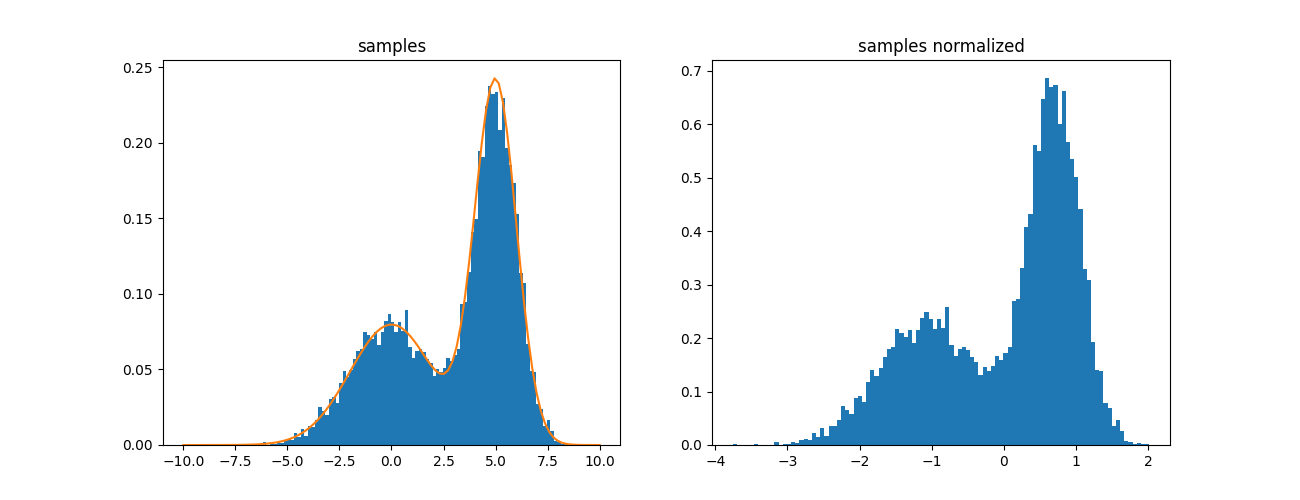

In [8]:
dist1 = torch.distributions.Normal(0, 2)
dist2 = torch.distributions.Normal(5, 1)
weights = torch.tensor([0.4, 0.6])

num_samples = 10000
cat = torch.distributions.Categorical(weights)
choices = cat.sample((num_samples,))
samples = torch.where(choices == 0, dist1.sample((num_samples,)), dist2.sample((num_samples,)))

sample_mean, sample_std = samples.mean(), samples.std()
samples_normalized = (samples - sample_mean) / sample_std

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].hist(samples, bins=100, density=True)
ax[0].set_title('samples')

x = torch.tensor(torch.linspace(-10, 10, 100))
ax[0].plot(x, weights[0] * dist1.log_prob(x).exp() + weights[1] * dist2.log_prob(x).exp())

ax[1].hist(samples_normalized, bins=100, density=True)
ax[1].set_title('samples normalized')
,

## Train diffusion model on samples

In [4]:
class Denoiser(torch.nn.Module):
    sigma_min = 0
    sigma_max = torch.inf

    def __init__(self):
        super(Denoiser, self).__init__()
        self.skip_layers = ()
        self.num_layers = 8
        self.init_radius = 0.5
        self.input_dim = 1
        self.hidden_dim = 512
        self.output_dim = 1
        self.linears = torch.nn.ModuleList()

        out_dim = self.hidden_dim if 1 not in self.skip_layers else (self.hidden_dim - self.input_dim)
        self.linears.append(torch.nn.Linear(self.input_dim + 1, out_dim))
        for i in range(2, self.num_layers + 1):
            in_dim = out_dim
            if i in self.skip_layers:
                in_dim += self.input_dim
            next_is_skip = (i + 1 in self.skip_layers)
            out_dim = self.hidden_dim if not next_is_skip else (self.hidden_dim - self.input_dim)
            self.linears.append(torch.nn.Linear(in_dim, out_dim))

        self.final_linear = torch.nn.Linear(out_dim, self.output_dim)

    def forward(self, x, sigma, labels=None):
        in_shape = x.shape
        sigmas = (torch.ones_like(x).squeeze() * sigma.squeeze()).reshape(-1, 1) # handle case of single sigma, or one per x

        c_skip = 1 / (sigmas ** 2 + 1)
        c_out = sigmas / (sigmas ** 2 + 1).sqrt()
        c_in = 1 / (sigmas ** 2 + 1).sqrt()
        c_noise = sigmas.log() / 4

        x_in = x.reshape(-1, 1)
        x = torch.cat([x_in * c_in, c_noise], dim=-1)
        for i, layer in enumerate(self.linears, start=1):
            x = torch.nn.functional.softplus(layer(x), beta=100)
        x_out = self.final_linear(x)

        return (c_skip * x_in  + c_out * x_out).reshape(in_shape)

    def round_sigma(self, sigma):
        return torch.as_tensor(sigma)


denoiser = Denoiser().to('cuda')

In [15]:
torch.random.manual_seed(0)


batch_size, n_batches = 5000, 50000
optimizer = torch.optim.Adam(denoiser.parameters(), lr=1e-3)
denoiser = denoiser.to(torch.float32)
for batch_idx in tqdm(range(n_batches)):
	optimizer.zero_grad()

	batch_indices = torch.randperm(samples_normalized.size(0))[:batch_size]
	sigmas = (torch.randn(batch_size) * 1.2 - 1.2).exp().to('cuda')

	batch_samples = samples_normalized[batch_indices].to('cuda')
	noise = torch.randn_like(batch_samples)

	x_prediction = denoiser(
		x=batch_samples + noise * sigmas,
		sigma=sigmas,
	)
	loss_weights = (1 + sigmas ** 2) / sigmas ** 2
	loss = (loss_weights * (x_prediction - batch_samples) ** 2).mean()

	loss.backward()
	optimizer.step()



  0%|          | 0/50000 [00:00<?, ?it/s]

In [37]:
from datetime import datetime
timestamp_str = datetime.now().strftime("%Y%m%d_%H%M%S")
torch.save(denoiser.state_dict(), f'denoiser_{timestamp_str}.pth')

In [5]:
checkpoint_path = 'toy_denoiser.pth'
state_dict = torch.load(checkpoint_path, map_location='cuda')
denoiser.load_state_dict(state_dict)
denoiser = denoiser.to('cuda').eval()

## Sample from diffusion model with reverse SDE

Check that samples from reverse SDE matches the closed-form pdf p(z)

In [10]:
def edm_sampler(
    net, latents, class_labels=None, randn_like=torch.randn_like,
    num_steps=18, sigma_min=0.000, sigma_max=float('inf'), rho=7,
    # S_churn=40, S_min=0.05, S_max=50, S_noise=1.003,
    S_churn=0, S_min=0, S_max=float('inf'), S_noise=1,
):
    # Adjust noise levels based on what's supported by the network.
    sigma_min = max(sigma_min, net.sigma_min)
    sigma_max = min(sigma_max, net.sigma_max)

    # Time step discretization.
    step_indices = torch.arange(num_steps, dtype=torch.float64, device=latents.device)
    t_steps = (sigma_max ** (1 / rho) + step_indices / (num_steps - 1) * (sigma_min ** (1 / rho) - sigma_max ** (1 / rho))) ** rho
    t_steps = torch.cat([net.round_sigma(t_steps), torch.zeros_like(t_steps[:1])]) # t_N = 0

    # Main sampling loop.
    x_next = latents.to(torch.float64) * t_steps[0]
    for i, (t_cur, t_next) in enumerate(zip(t_steps[:-1], t_steps[1:])): # 0, ..., N-1
        x_cur = x_next

        # Increase noise temporarily.
        gamma = min(S_churn / num_steps, np.sqrt(2) - 1) if S_min <= t_cur <= S_max else 0
        t_hat = net.round_sigma(t_cur + gamma * t_cur)
        x_hat = x_cur + (t_hat ** 2 - t_cur ** 2).sqrt() * S_noise * randn_like(x_cur)

        # Euler step.
        denoised = net(x_hat, t_hat, class_labels).to(torch.float64)
        d_cur = (x_hat - denoised) / t_hat
        x_next = x_hat + (t_next - t_hat) * d_cur

        # Apply 2nd order correction.
        if i < num_steps - 1:
            denoised = net(x_next, t_next, class_labels).to(torch.float64)
            d_prime = (x_next - denoised) / t_next
            x_next = x_hat + (t_next - t_hat) * (0.5 * d_cur + 0.5 * d_prime)

    return x_next


n_samples = 5000
init_latents = torch.randn((n_samples, 1, 1), device='cuda')
with torch.no_grad():
	samples = edm_sampler(denoiser.to(torch.float64), init_latents.to(torch.float64), sigma_min=0.002, sigma_max=100)

/tmp/ipykernel_108447/147174344.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(torch.linspace(-10, 10, 100))


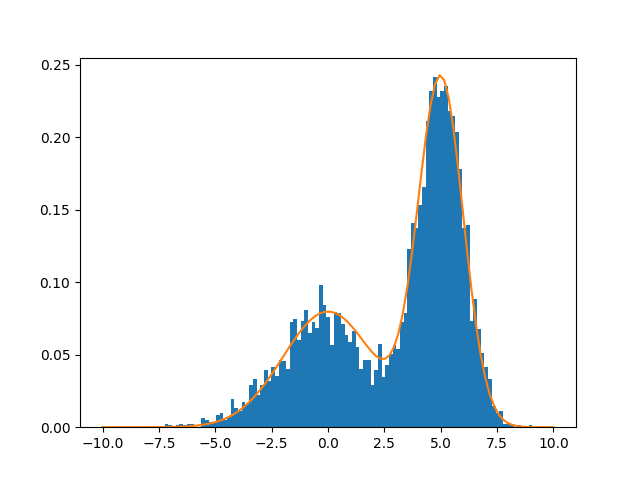

In [11]:
fig, ax = plt.subplots(1, 1)
ax.hist((sample_std * samples + sample_mean).detach().cpu().numpy()[:, 0, 0], bins=100, density=True)
x = torch.tensor(torch.linspace(-10, 10, 100))
ax.plot(x, weights[0] * dist1.log_prob(x).exp() + weights[1] * dist2.log_prob(x).exp())


Check that the estimated score function matches the closed-form score function

/tmp/ipykernel_108447/2447800773.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(torch.linspace(-10, 10, 100), device='cuda', requires_grad=False)


interactive(children=(FloatSlider(value=0.0, continuous_update=False, description='sigma', max=40.0), Output()…

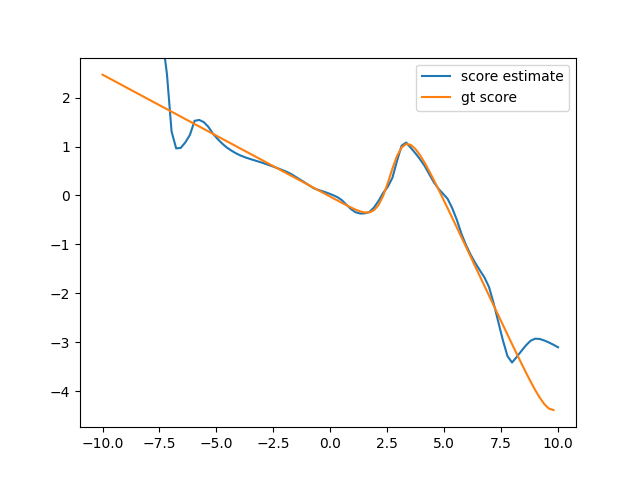

In [12]:
fig, ax = plt.subplots(1, 1)
x = torch.tensor(torch.linspace(-10, 10, 100), device='cuda', requires_grad=False)

score_estimate, gt_score = None, None
def update(sigma):
    global score_estimate, gt_score
    sigma = torch.tensor(sigma, device='cuda', dtype=torch.float32, requires_grad=False)
    x_denoised = sample_std * denoiser.to(torch.float32)((x.to('cuda', torch.float32) - sample_mean) / sample_std, sigma) + sample_mean
    score_function = ((x_denoised - x) / (sigma * sample_std) ** 2).detach().cpu().numpy()
    # score_function = (-x_denoised / (sigma * sample_std)).detach().cpu().numpy()

    noisy_dist1 = torch.distributions.Normal(0, np.sqrt(2 ** 2 + sigma.item() ** 2))
    noisy_dist2 = torch.distributions.Normal(5, np.sqrt(1 ** 2 + sigma.item() ** 2))
    gt_score_function = np.diff(torch.log(weights[0] * noisy_dist1.log_prob(x).exp() + weights[1] * noisy_dist2.log_prob(x).exp()).cpu().numpy()) / np.diff(x.cpu().numpy())

    if score_estimate is None:
        score_estimate = ax.plot(x.detach().cpu().numpy(), score_function, label='score estimate')[0]
        gt_score = ax.plot(
            x.cpu().numpy()[:-1],
            gt_score_function,
            label='gt score'
        )[0]
        ax.legend()
        # ax.set_ylim(0, 0.26)
    else:
        score_estimate.set_ydata(score_function)
        gt_score.set_ydata(gt_score_function)
    fig.canvas.draw_idle()

slider = ipywidgets.FloatSlider(val=0.01, min=0, max=40, continuous_update=False)
ipywidgets.interact(update, sigma=slider)
slider.value = 0.1

## Sample with Half-denoising Langevin dynamics

Check that the samples match the closed-form pdf p(z)

In [13]:
torch.random.manual_seed(1)
denoiser = denoiser.to(torch.float32)

sigma = torch.tensor(0.05, device='cuda')

xts = []
n_samples = 5000
xt = torch.randn(n_samples, device='cuda')
with torch.no_grad():
	for i in tqdm(range(10000)):
		xts.append(xt.detach().clone().cpu())
		noise = torch.randn_like(xt)
		xt_noised = xt + noise * sigma
		xt = xt_noised - .5 * (xt_noised - denoiser(xt_noised, sigma))
xts = torch.stack(xts)

  0%|          | 0/10000 [00:00<?, ?it/s]

/tmp/ipykernel_108447/1715803415.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(torch.linspace(-10, 10, 100))


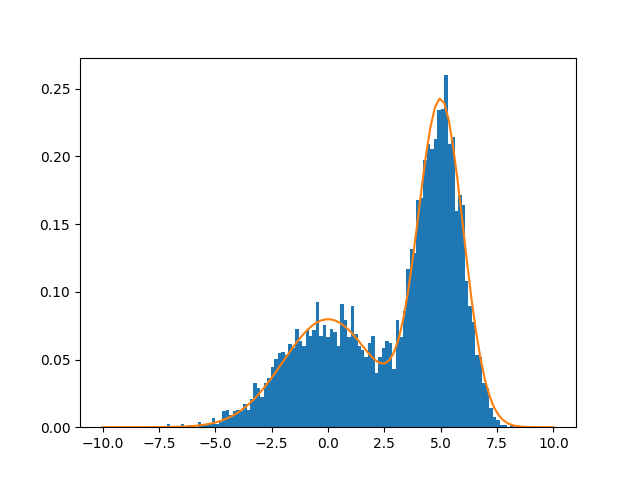

In [14]:
fig, ax = plt.subplots(1, 1)
ax.hist((sample_std * xts[-1] + sample_mean).detach().cpu().numpy(), bins=100, density=True)

x = torch.tensor(torch.linspace(-10, 10, 100))
ax.plot(x, weights[0] * dist1.log_prob(x).exp() + weights[1] * dist2.log_prob(x).exp())

/tmp/ipykernel_108447/782442438.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(torch.linspace(-10, 10, 100))


interactive(children=(IntSlider(value=0, continuous_update=False, description='i', max=9999), Output()), _dom_…

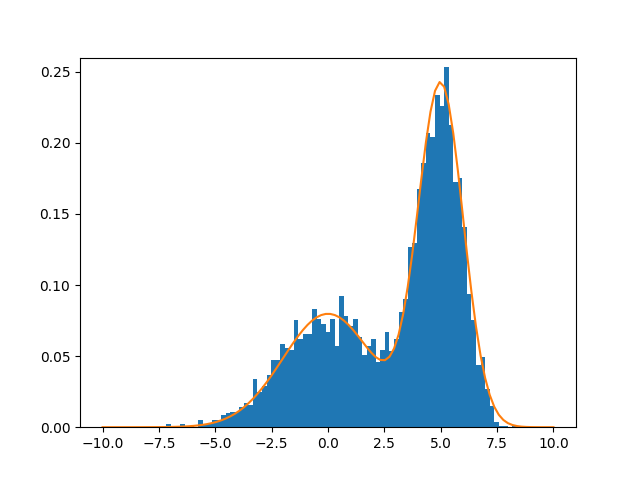

In [15]:
import ipywidgets
fig, ax = plt.subplots(1, 1)
bins = np.linspace(-10, 10, 100)

x = torch.tensor(torch.linspace(-10, 10, 100))

histogram_plot = None
fig.canvas.draw_idle()

def update(i):
    global histogram_plot
    if histogram_plot is None:
        _, _, histogram_plot = ax.hist((sample_std * xts + sample_mean)[i].cpu(), bins=bins, density=True)
        ax.plot(x, weights[0] * dist1.log_prob(x).exp() + weights[1] * dist2.log_prob(x).exp())
        ax.set_ylim(0, 0.26)
    else:
        histogram_values, _ = np.histogram((sample_std * xts + sample_mean)[i].cpu(), density=True, bins=bins)
        for bar, value in zip(histogram_plot, histogram_values):
            bar.set_height(value)

    fig.canvas.draw_idle()

# ax_slider = plt.axes([0.1, 0.02, 0.8, 0.05])
slider = ipywidgets.IntSlider(val=len(xts) - 1, min=0, max=len(xts) - 1, continuous_update=False)
ipywidgets.interact(update, i=slider)
slider.value = len(xts) - 1

## Sample with GG-Langevin

Check that samples match the closed-form geometry-guided distribution

In [50]:
torch.random.manual_seed(1)

init_sample = torch.tensor(-1., device='cuda')
sigma = torch.tensor(0.05, device='cuda')

mu, beta = -2.5 + 1, 1.5 / 4 # example 1 (uncomment here and below to swap example)
# mu, beta = -8, 0.4 # example 2
mu_normalized = (mu - sample_mean) / sample_std
beta_normalized = beta * sample_std

denoiser = denoiser.to(torch.float32)
xts_gg = []
n_samples = 5000
xt = torch.randn(n_samples, device='cuda')
with torch.no_grad():
	for i in tqdm(range(10000)):
		xts_gg.append(xt.detach().clone().cpu())
		noise = torch.randn_like(xt)
		xt_noised = xt + noise * sigma
		xt = xt_noised + .5 * (denoiser(xt_noised, sigma) - xt_noised) - sigma ** 2 * beta_normalized * (xt - mu_normalized) # example 1
		# xt = xt_noised + .5 * (denoiser(xt_noised, sigma) - xt_noised) - .5 * sigma ** 2 * beta_normalized * torch.sign(xt - mu_normalized) # example 2
xts_gg = torch.stack(xts_gg)

  0%|          | 0/10000 [00:00<?, ?it/s]

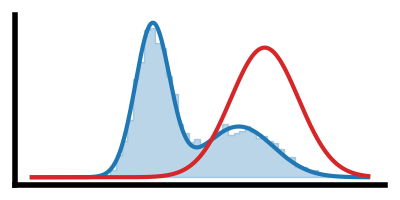

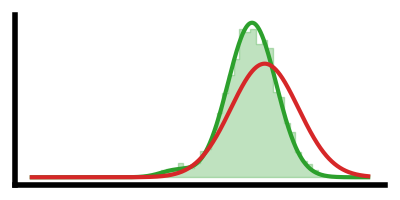

In [51]:
x_start, x_end = (-7.5, 12)
end_step = 10000 - 1
for i, (name, xts_denormalized, sample_indices) in enumerate([
		('langevin', xts * sample_std + sample_mean, (6, 29)),
		('gg_langevin', xts_gg * sample_std + sample_mean, (1,)),
	]):
	fig, ax = plt.subplots(1, 1, figsize=(4, 2))
	density_start, edges = np.histogram(xts_denormalized[0], bins=60, range=(x_start, x_end), density=True)
	density_end, _ = np.histogram(xts_denormalized[end_step], bins=60, range=(x_start, x_end), density=True)

	ax.fill_between(
		np.repeat(edges, 2)[1:-1],
		1,
		np.repeat(1 + density_end, 2)[::-1],
		alpha=0.3,
		color=mpl_colors[0] if i == 0 else mpl_colors[2]
	)

	x = np.linspace(x_start, x_end, 1000)
	guidance_distribution = torch.exp(-beta_normalized * ((x - mu) / sample_std) ** 2) # example 1
	# guidance_distribution = torch.exp(-beta_normalized * ((x - mu) / sample_std) ** 1) # example 2
	guidance_distribution /= (x[1] - x[0]) * guidance_distribution.sum()

	data_distribution = weights[0] * dist1.log_prob(torch.tensor(x)).exp() + weights[1] * dist2.log_prob(torch.tensor(x)).exp()
	product_distribution = guidance_distribution * data_distribution
	product_distribution /= (x[1] - x[0]) * product_distribution.sum()

	if i == 0:
		ax.plot(x, 1 + data_distribution.numpy()[::-1], color=mpl_colors[0], linewidth=3)
	if i == 1:
		ax.plot(x, 1 + product_distribution.numpy()[::-1], color=mpl_colors[2], linewidth=3)
	ax.plot(x, 1 + guidance_distribution.numpy()[::-1], color=mpl_colors[3], linewidth=3)

	# remove borders but keep xy axis
	ax.spines['top'].set_visible(False)
	ax.spines['right'].set_visible(False)
	ax.tick_params(left=False, bottom=False)
	ax.set_xticklabels([])
	ax.set_yticklabels([])
	for spine in ax.spines.values():
		spine.set_linewidth(4)

	fig.tight_layout()

	timestamp_str = datetime.now().strftime('%Y%m%d_%H%M%S')
	fig.savefig(f'images/{name}_{timestamp_str}.png', bbox_inches='tight', pad_inches=0.1, transparent=True)
	fig.savefig(f'images/{name}_{timestamp_str}.svg', bbox_inches='tight', pad_inches=0.1, transparent=True)



### Visualize sample trajectories

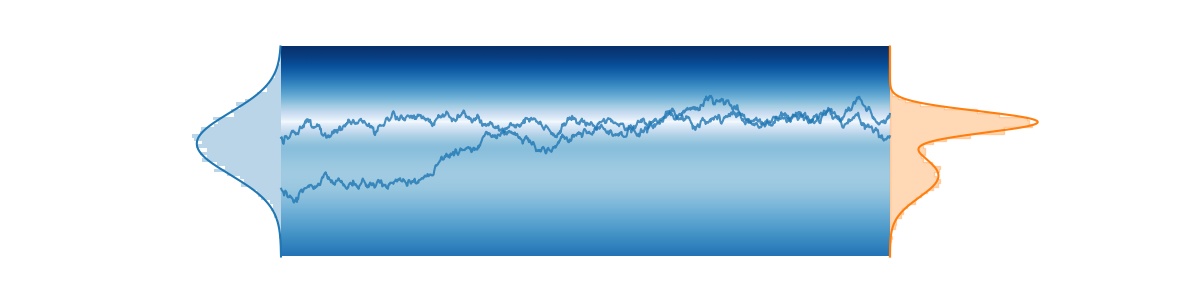

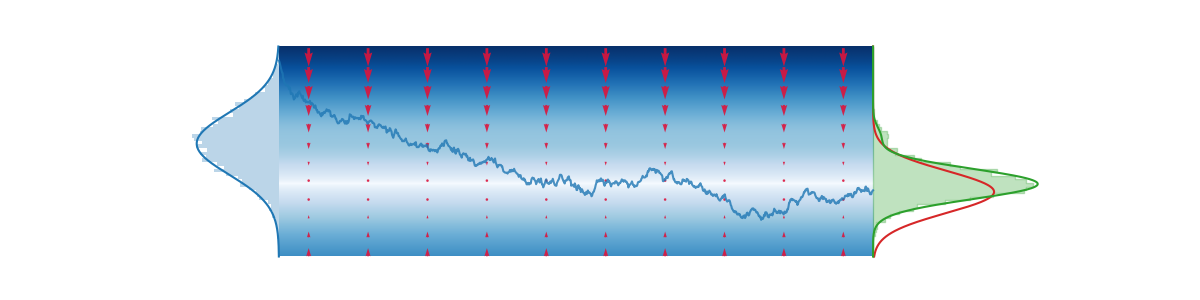

In [ ]:
for i, (name, xts_denormalized, sample_indices) in enumerate([
		('langevin', xts * sample_std + sample_mean, (6, 29)),
		('gg_langevin', xts_gg * sample_std + sample_mean, (1,)),
	]):
	fig, ax = plt.subplots(1, 1, figsize=(12, 3))
	end_step = 1000 - 1

	x_start, x_end = (-7.5, 12)
	density_start, edges = np.histogram(xts_denormalized[0], bins=60, range=(x_start, x_end), density=True)
	density_end, _ = np.histogram(xts_denormalized[end_step], bins=60, range=(x_start, x_end), density=True)

	ax.fill_betweenx(
		np.repeat(edges, 2)[1:-1],
		np.repeat(0 - density_start, 2),
		0,
		alpha=0.3
	)

	ax.fill_betweenx(
		np.repeat(edges, 2)[1:-1],
		1,
		np.repeat(1 + density_end, 2),
		alpha=0.3,
		color=mpl_colors[1] if i == 0 else mpl_colors[2]
	)

	x = np.linspace(x_start, x_end, 1000)
	guidance_distribution = torch.exp(-beta_normalized * ((x - mu) / sample_std) ** 2)
	guidance_distribution /= (x[1] - x[0]) * guidance_distribution.sum()

	data_distribution = weights[0] * dist1.log_prob(torch.tensor(x)).exp() + weights[1] * dist2.log_prob(torch.tensor(x)).exp()
	product_distribution = guidance_distribution * data_distribution
	product_distribution /= (x[1] - x[0]) * product_distribution.sum()

	if i == 0:
		ax.plot(1 + data_distribution, x, color=mpl_colors[1])
	if i == 1:
		ax.plot(1 + guidance_distribution, x, color=mpl_colors[3])
		ax.plot(1 + product_distribution, x, color=mpl_colors[2])

	ax.plot(-np.exp(-(x - sample_mean.numpy()) ** 2 / sample_std ** 2 / 2) / np.sqrt(2 * np.pi) / sample_std, x, color=mpl_colors[0])



	step = 1
	for sample_idx in sample_indices:
		ax.plot(
			np.linspace(0, 1, end_step // step),
			xts_denormalized[:end_step:step, sample_idx],
			color=mpl_colors[0],
			alpha=0.8
		)

	x = torch.tensor(np.linspace(x_start, x_end, 1000))
	gt_logprob = -(np.log(data_distribution) if i == 0 else np.log(product_distribution))

	if i == 1:
		for t in np.linspace(0.05, 0.95, 10):
			arrow_step = 90
			guidance_gradient = np.gradient(np.log(guidance_distribution.detach().cpu().numpy()))[1::arrow_step]
			ax.quiver(
				np.ones(len(guidance_gradient)) * t,
				x[1::arrow_step],
				np.zeros(len(guidance_gradient)),
				guidance_gradient * 25,
				angles='xy', scale_units='xy', scale=1,
				color='crimson', width=0.003, headwidth=3, alpha=0.9
			)


	xlim, ylim = ax.get_xlim(), ax.get_ylim()
	ax.imshow(
		np.stack([(gt_logprob - gt_logprob.min()) ** 0.35] * 1000).T,
		extent=(0,1,x_start,x_end), origin="lower",
		aspect='auto',
		cmap='Blues',
	)
	ax.set_xlim(xlim)
	ax.set_ylim(ylim)

	# remove axes
	ax.axis('off')